In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "adult"
namex = "Adult "
d = 14

###knn
graphsz = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)
###threshold
graphsx = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


# See graphs stats

## Nearest neighbor

In [3]:
graphsinforg0, graphsinforg1 = [], []

for iz, graph in enumerate(graphsz):
    
    g0edges = {u: e for u, e in graph["edges"].items() if graph["agent_protectatts"].get(u) == 0}
    g1edges = {u: e for u, e in graph["edges"].items() if graph["agent_protectatts"].get(u) == 1}

    graphsinforg0.append(scripts.analytics.group_graph_info(graph, g0edges, namex, d, iz))
    graphsinforg1.append(scripts.analytics.group_graph_info(graph, g1edges, namex, d, iz))


randomgraphsinfog0 = pd.DataFrame(graphsinforg0)
randomgraphsinfog1 = pd.DataFrame(graphsinforg1)

randomgraphsinfog0

,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),1,108,46,10,36,1.0,0.19,0.81,4.15,0.07,0.03,0.04,20,88,0,0,0
1,Adult (14),2,108,49,12,37,2.0,0.26,1.74,6.97,0.26,0.06,0.20,0,80,0,0,1
2,Adult (14),3,108,49,12,37,3.0,0.40,2.60,9.26,0.57,0.13,0.44,0,65,0,0,2
3,Adult (14),4,108,49,12,37,4.0,0.55,3.45,10.29,0.92,0.22,0.70,0,52,0,0,3
4,Adult (14),5,108,49,12,37,5.0,0.73,4.27,12.56,1.39,0.34,1.05,0,35,0,0,4
5,Adult (14),6,108,49,12,37,6.0,0.88,5.12,14.40,1.85,0.39,1.46,0,26,0,0,5
6,Adult (14),7,108,49,12,37,7.0,1.06,5.94,16.43,2.34,0.48,1.86,0,20,0,0,6
7,Adult (14),8,108,49,12,37,8.0,1.35,6.65,18.38,2.90,0.64,2.26,0,13,0,0,7
8,Adult (14),9,108,49,12,37,9.0,1.60,7.40,19.84,3.39,0.74,2.65,0,8,0,0,8
9,Adult (14),10,108,49,12,37,10.0,1.84,8.16,22.04,3.99,0.87,3.12,0,8,0,0,9


In [4]:
randomgraphsinfog1

,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),1,220,46,10,36,1.0,0.23,0.77,6.11,0.05,0.01,0.04,50,170,0,0,0
1,Adult (14),2,220,49,12,37,2.0,0.60,1.40,10.48,0.15,0.05,0.10,15,104,0,0,1
2,Adult (14),3,220,49,12,37,3.0,0.96,2.04,15.71,0.37,0.15,0.22,4,56,0,0,2
3,Adult (14),4,220,49,12,37,4.0,1.34,2.66,20.47,0.70,0.31,0.38,2,34,0,0,3
4,Adult (14),5,220,49,12,37,5.0,1.74,3.26,24.44,1.10,0.54,0.56,1,26,0,0,4
5,Adult (14),6,220,49,12,37,6.0,2.14,3.86,29.33,1.59,0.80,0.79,0,18,0,0,5
6,Adult (14),7,220,49,12,37,7.0,2.47,4.53,32.08,2.12,1.03,1.08,0,13,0,0,6
7,Adult (14),8,220,49,12,37,8.0,2.84,5.16,36.67,2.69,1.29,1.41,0,6,0,0,7
8,Adult (14),9,220,49,12,37,9.0,3.22,5.78,40.41,3.33,1.59,1.74,0,4,0,0,8
9,Adult (14),10,220,49,12,37,10.0,3.50,6.50,44.90,3.97,1.83,2.14,0,2,0,0,9


## Thresholding

In [5]:
graphsinforxg0, graphsinforxg1 = [], []

for ix, grx in enumerate(graphsx):
    
    g0xedges = {ux: ex for ux, ex in grx["edges"].items() if grx["agent_protectatts"].get(ux) == 0}
    g1xedges = {ux: ex for ux, ex in grx["edges"].items() if grx["agent_protectatts"].get(ux) == 1}

    graphsinforxg0.append(scripts.analytics.group_graph_info(grx, g0xedges, namex, d, ix, True))
    graphsinforxg1.append(scripts.analytics.group_graph_info(grx, g1xedges, namex, d, ix, True))


randomgraphsinfoxg0 = pd.DataFrame(graphsinforxg0)
randomgraphsinfoxg1 = pd.DataFrame(graphsinforxg1)

randomgraphsinfoxg0

,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),4.0,108,48,12,36,7.68,1.73,5.94,19.28,2.19,0.56,1.63,1,24,15,0,0
1,Adult (14),4.5,108,49,12,37,14.44,3.07,11.36,33.89,6.22,1.35,4.87,0,16,9,0,1
2,Adult (14),5.0,108,49,12,37,22.30,4.82,17.47,50.17,12.88,2.79,10.09,1,9,4,0,2
3,Adult (14),5.5,108,49,12,37,29.90,6.67,23.23,65.90,21.03,4.64,16.39,0,4,2,0,3
4,Adult (14),6.0,108,49,12,37,36.73,8.39,28.34,80.96,29.80,6.51,23.29,0,3,0,0,4
5,Adult (14),6.5,108,49,12,37,41.64,9.71,31.93,91.78,36.85,8.25,28.60,0,1,0,0,5
6,Adult (14),7.0,108,49,12,37,45.01,10.81,34.19,99.20,42.11,9.87,32.24,0,1,0,4,6
7,Adult (14),7.5,108,49,12,37,46.91,11.44,35.46,103.39,45.24,10.95,34.30,0,0,0,3,7
8,Adult (14),8.0,108,49,12,37,48.04,11.80,36.24,105.88,47.21,11.60,35.61,0,0,0,4,8
9,Adult (14),8.5,108,49,12,37,48.65,11.91,36.74,107.22,48.31,11.82,36.49,0,0,0,6,9


In [6]:
randomgraphsinfoxg1

,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),4.0,220,48,12,36,15.16,4.70,10.46,70.96,6.98,2.44,4.54,5,27,20,0,0
1,Adult (14),4.5,220,49,12,37,22.05,6.34,15.72,99.02,12.55,3.94,8.62,2,17,12,0,1
2,Adult (14),5.0,220,49,12,37,29.31,7.88,21.44,131.61,20.02,5.63,14.39,1,11,5,0,2
3,Adult (14),5.5,220,49,12,37,35.22,9.17,26.05,158.12,27.36,7.24,20.12,0,5,4,0,3
4,Adult (14),6.0,220,49,12,37,40.04,10.21,29.83,179.78,34.17,8.78,25.39,0,3,2,0,4
5,Adult (14),6.5,220,49,12,37,43.41,11.01,32.40,194.92,39.38,10.14,29.24,1,3,0,1,5
6,Adult (14),7.0,220,49,12,37,46.04,11.52,34.52,206.69,43.66,11.06,32.60,0,1,0,0,6
7,Adult (14),7.5,220,49,12,37,47.57,11.82,35.75,213.57,46.31,11.64,34.67,0,0,0,0,7
8,Adult (14),8.0,220,49,12,37,48.36,11.93,36.43,217.14,47.77,11.86,35.91,0,0,0,4,8
9,Adult (14),8.5,220,49,12,37,48.72,11.99,36.74,218.76,48.46,11.97,36.49,0,0,0,9,9


# Compute greedy and random algorithms results

## Nearest neighbor

In [7]:
resdf = scripts.analytics.fairness_greedy_random(bgraphs=graphsz, 
                                                    dname=name+" ("+ str(d) + ")", 
                                                    budgets=(0, 2, 4, 6))

In [8]:
resdf["summary"].to_csv("./fairness/"+name+"_knn_summary_fair.csv", index=False)
resdf["summary_g0"].to_csv("./fairness/"+name+"_knn_summary_group0_fair.csv", index=False)
resdf["summary_g1"].to_csv("./fairness/"+name+"_knn_summary_group1_fair.csv", index=False)
resdf["greedy"].to_csv("./fairness/"+name+"_knn_greedyheuristic_fair.csv", index=False)
resdf["random"].to_csv("./fairness/"+name+"_knn_randomheuristic_fair.csv", index=False)
resdf["group_results"].to_csv("./fairness/"+name+"_knn_groupsresults_fair.csv", index=False)


In [9]:
resdf["group_results"].head()

,K,kmax,n,n_g0,n_g1,m,dataset,graphid,g0F(Sg+ U Sg-)*,g1F(Sg+ U Sg-)*,...,g0-F(Sg),g1-F(Sg),g0Qx(Sg),g1Qx(Sg),g0F(Sr),g1F(Sr),g0-F(Sr),g1-F(Sr),g0Qx(Sr),g1Qx(Sr)
0,0,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0...."
1,2,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: 0....","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0...."
2,4,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0, 1: 0.0, 3: 0, 5: 0, 10: 0.0, 13: 0.0, 1...","{2: 0.0, 4: 0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0,..."
3,6,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0, 1: 0.0, 3: 0, 5: 0, 10: 0.0, 13: 0.0, 1...","{2: 0.0, 4: 0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0,..."
4,0,2,328,108,220,49,adult (14),1,0.129630,0.297727,...,0.129630,0.297727,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.5, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.129630,0.297727,0.129630,0.297727,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.5, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0...."


## Thresholding

In [10]:
resdfx = scripts.analytics.fairness_greedy_random(bgraphs=graphsx, 
                                                    dname=name+" ("+ str(d) + ")", 
                                                    budgets=(0, 2, 4, 6),  
                                                    thresh=True)

In [11]:
resdfx["summary"].to_csv("./fairness/"+name+"_thresh_summary_fair.csv", index=False)
resdfx["summary_g0"].to_csv("./fairness/"+name+"_thresh_summary_group0_fair.csv", index=False)
resdfx["summary_g1"].to_csv("./fairness/"+name+"_thresh_summary_group1_fair.csv", index=False)
resdfx["greedy"].to_csv("./fairness/"+name+"_thresh_greedyheuristic_fair.csv", index=False)
resdfx["random"].to_csv("./fairness/"+name+"_thresh_randomheuristic_fair.csv", index=False)
resdfx["group_results"].to_csv("./fairness/"+name+"_thresh_groupsresults_fair.csv", index=False)


In [12]:
resdfx["group_results"].head()

,K,r,n,n_g0,n_g1,m,dataset,graphid,g0F(Sg+ U Sg-)*,g1F(Sg+ U Sg-)*,...,g0-F(Sg),g1-F(Sg),g0Qx(Sg),g1Qx(Sg),g0F(Sr),g1F(Sr),g0-F(Sr),g1-F(Sr),g0Qx(Sr),g1Qx(Sr)
0,0,4.0,328,108,220,48,adult (14),0,0.166406,0.267576,...,0.166406,0.267576,"{0: 0.29411764705882354, 1: 0.3125, 3: 0.33333...","{2: 0.375, 4: 0, 6: 0.35294117647058826, 7: 0....",0.166406,0.267576,0.166406,0.267576,"{0: 0.29411764705882354, 1: 0.3125, 3: 0.33333...","{2: 0.375, 4: 0, 6: 0.35294117647058826, 7: 0...."
1,2,4.0,328,108,220,48,adult (14),0,0.622722,0.745378,...,0.587898,0.739858,"{0: 1, 1: 1, 3: 1, 5: 1, 10: 1, 13: 1, 17: 0, ...","{2: 1, 4: 0, 6: 1, 7: 1, 8: 0.0, 9: 1, 11: 1, ...",0.166957,0.274989,0.166957,0.274989,"{0: 0.29411764705882354, 1: 0.3125, 3: 0.33333...","{2: 0.375, 4: 0, 6: 0.35294117647058826, 7: 0...."
2,4,4.0,328,108,220,48,adult (14),0,0.630952,0.771515,...,0.624339,0.757435,"{0: 1, 1: 1, 3: 1, 5: 1, 10: 1, 13: 1, 17: 0, ...","{2: 1, 4: 0, 6: 1, 7: 1, 8: 0.0, 9: 1, 11: 1, ...",0.187607,0.280031,0.166957,0.274989,"{0: 0.3125, 1: 0.3333333333333333, 3: 0.4, 5: ...","{2: 0.375, 4: 0, 6: 0.375, 7: 0.31818181818181..."
3,6,4.0,328,108,220,48,adult (14),0,0.630952,0.786364,...,0.632275,0.768268,"{0: 1, 1: 1, 3: 1, 5: 1, 10: 1, 13: 1, 17: 0, ...","{2: 1, 4: 0, 6: 1, 7: 1, 8: 0.0, 9: 1, 11: 1, ...",0.194668,0.401753,0.187607,0.277288,"{0: 0.3333333333333333, 1: 0.3333333333333333,...","{2: 0.4, 4: 0, 6: 0.375, 7: 1, 8: 0.0, 9: 1, 1..."
4,0,4.5,328,108,220,49,adult (14),1,0.163389,0.262044,...,0.163389,0.262044,"{0: 0.2222222222222222, 1: 0.2692307692307692,...","{2: 0.26666666666666666, 4: 0, 6: 0.3076923076...",0.163389,0.262044,0.163389,0.262044,"{0: 0.2222222222222222, 1: 0.2692307692307692,...","{2: 0.26666666666666666, 4: 0, 6: 0.3076923076..."


# Compute greedy and random algorithms results

## Nearest neighbor

### fairness

In [13]:
resdf = scripts.analytics.fairness_greedy_random(bgraphs=graphsz, 
                                                    dname=name+" ("+ str(d) + ")", 
                                                    budgets=(0, 2, 4, 6))

In [14]:
resdf["summary"].to_csv("./fairness/"+name+"_knn_summary_fair.csv", index=False)
resdf["summary_g0"].to_csv("./fairness/"+name+"_knn_summary_group0_fair.csv", index=False)
resdf["summary_g1"].to_csv("./fairness/"+name+"_knn_summary_group1_fair.csv", index=False)
resdf["greedy"].to_csv("./fairness/"+name+"_knn_greedyheuristic_fair.csv", index=False)
resdf["random"].to_csv("./fairness/"+name+"_knn_randomheuristic_fair.csv", index=False)
resdf["group_results"].to_csv("./fairness/"+name+"_knn_groupsresults_fair.csv", index=False)


In [15]:
resdf["group_results"].head()

,K,kmax,n,n_g0,n_g1,m,dataset,graphid,g0F(Sg+ U Sg-)*,g1F(Sg+ U Sg-)*,...,g0-F(Sg),g1-F(Sg),g0Qx(Sg),g1Qx(Sg),g0F(Sr),g1F(Sr),g0-F(Sr),g1-F(Sr),g0Qx(Sr),g1Qx(Sr)
0,0,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0...."
1,2,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: 0....","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0...."
2,4,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0, 1: 0.0, 3: 0, 5: 0, 10: 0.0, 13: 0.0, 1...","{2: 0.0, 4: 0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0,..."
3,6,1,328,108,220,46,adult (14),0,0.185185,0.227273,...,0.185185,0.227273,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.185185,0.227273,0.185185,0.227273,"{0: 0, 1: 0.0, 3: 0, 5: 0, 10: 0.0, 13: 0.0, 1...","{2: 0.0, 4: 0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0,..."
4,0,2,328,108,220,49,adult (14),1,0.129630,0.297727,...,0.129630,0.297727,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.5, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0....",0.129630,0.297727,0.129630,0.297727,"{0: 0.0, 1: 0.0, 3: 0.0, 5: 0.0, 10: 0.0, 13: ...","{2: 0.0, 4: 0.5, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0...."


### alt fairness

In [16]:
dfz = scripts.analytics.alt_fairness_greedy(bgraphs=graphsz,
                                            dname = name+" ("+ str(d) + ")")


dfz.to_csv("./fairness/"+name+"_knn_summary_altgreedy_fair.csv", index=False)


################
################
sdfz = dfz[(dfz["F(Sg)"] != dfz["F(Sg0)"]) | (dfz["F(Sg)"] != dfz["F(Sg1)"])]

sdfz[['K', 'kmax', 'n', 'm', 'Sg', 'F(Sg)', 'g0F(Sg)', 'g1F(Sg)', 'Sg0', 'F(Sg0)',\
      'g0F(Sg0)', 'g1F(Sg0)', 'Sg1', 'F(Sg1)', 'g0F(Sg1)','g1F(Sg1)']]

,K,kmax,n,m,Sg,F(Sg),g0F(Sg),g1F(Sg),Sg0,F(Sg0),g0F(Sg0),g1F(Sg0),Sg1,F(Sg1),g0F(Sg1),g1F(Sg1)


## Thresholding

### fairness

In [17]:
resdfx = scripts.analytics.fairness_greedy_random(bgraphs=graphsx, 
                                                    dname=name+" ("+ str(d) + ")", 
                                                    budgets=(0, 2, 4, 6),  
                                                    thresh=True)

In [18]:
resdfx["summary"].to_csv("./fairness/"+name+"_thresh_summary_fair.csv", index=False)
resdfx["summary_g0"].to_csv("./fairness/"+name+"_thresh_summary_group0_fair.csv", index=False)
resdfx["summary_g1"].to_csv("./fairness/"+name+"_thresh_summary_group1_fair.csv", index=False)
resdfx["greedy"].to_csv("./fairness/"+name+"_thresh_greedyheuristic_fair.csv", index=False)
resdfx["random"].to_csv("./fairness/"+name+"_thresh_randomheuristic_fair.csv", index=False)
resdfx["group_results"].to_csv("./fairness/"+name+"_thresh_groupsresults_fair.csv", index=False)


In [19]:
resdfx["group_results"].head()

,K,r,n,n_g0,n_g1,m,dataset,graphid,g0F(Sg+ U Sg-)*,g1F(Sg+ U Sg-)*,...,g0-F(Sg),g1-F(Sg),g0Qx(Sg),g1Qx(Sg),g0F(Sr),g1F(Sr),g0-F(Sr),g1-F(Sr),g0Qx(Sr),g1Qx(Sr)
0,0,4.0,328,108,220,48,adult (14),0,0.166406,0.267576,...,0.166406,0.267576,"{0: 0.29411764705882354, 1: 0.3125, 3: 0.33333...","{2: 0.375, 4: 0, 6: 0.35294117647058826, 7: 0....",0.166406,0.267576,0.166406,0.267576,"{0: 0.29411764705882354, 1: 0.3125, 3: 0.33333...","{2: 0.375, 4: 0, 6: 0.35294117647058826, 7: 0...."
1,2,4.0,328,108,220,48,adult (14),0,0.622722,0.745378,...,0.587898,0.739858,"{0: 1, 1: 1, 3: 1, 5: 1, 10: 1, 13: 1, 17: 0, ...","{2: 1, 4: 0, 6: 1, 7: 1, 8: 0.0, 9: 1, 11: 1, ...",0.166957,0.274989,0.166957,0.274989,"{0: 0.29411764705882354, 1: 0.3125, 3: 0.33333...","{2: 0.375, 4: 0, 6: 0.35294117647058826, 7: 0...."
2,4,4.0,328,108,220,48,adult (14),0,0.630952,0.771515,...,0.624339,0.757435,"{0: 1, 1: 1, 3: 1, 5: 1, 10: 1, 13: 1, 17: 0, ...","{2: 1, 4: 0, 6: 1, 7: 1, 8: 0.0, 9: 1, 11: 1, ...",0.187607,0.280031,0.166957,0.274989,"{0: 0.3125, 1: 0.3333333333333333, 3: 0.4, 5: ...","{2: 0.375, 4: 0, 6: 0.375, 7: 0.31818181818181..."
3,6,4.0,328,108,220,48,adult (14),0,0.630952,0.786364,...,0.632275,0.768268,"{0: 1, 1: 1, 3: 1, 5: 1, 10: 1, 13: 1, 17: 0, ...","{2: 1, 4: 0, 6: 1, 7: 1, 8: 0.0, 9: 1, 11: 1, ...",0.194668,0.401753,0.187607,0.277288,"{0: 0.3333333333333333, 1: 0.3333333333333333,...","{2: 0.4, 4: 0, 6: 0.375, 7: 1, 8: 0.0, 9: 1, 1..."
4,0,4.5,328,108,220,49,adult (14),1,0.163389,0.262044,...,0.163389,0.262044,"{0: 0.2222222222222222, 1: 0.2692307692307692,...","{2: 0.26666666666666666, 4: 0, 6: 0.3076923076...",0.163389,0.262044,0.163389,0.262044,"{0: 0.2222222222222222, 1: 0.2692307692307692,...","{2: 0.26666666666666666, 4: 0, 6: 0.3076923076..."


### alt fairness

In [20]:
dfx = scripts.analytics.alt_fairness_greedy(bgraphs=graphsx,
                                            dname = name+" ("+ str(d) + ")",
                                            thresh=True)


dfx.to_csv("./fairness/"+name+"_thresh_summary_altgreedy_fair.csv", index=False)


################
################
sdfx = dfx[(dfx["F(Sg)"] != dfx["F(Sg0)"]) | (dfx["F(Sg)"] != dfx["F(Sg1)"])]

sdfx[['K', 'r', 'n', 'm', 'Sg', 'F(Sg)', 'g0F(Sg)', 'g1F(Sg)', 'Sg0', 'F(Sg0)',\
      'g0F(Sg0)', 'g1F(Sg0)', 'Sg1', 'F(Sg1)', 'g0F(Sg1)','g1F(Sg1)']]


,K,r,n,m,Sg,F(Sg),g0F(Sg),g1F(Sg),Sg0,F(Sg0),g0F(Sg0),g1F(Sg0),Sg1,F(Sg1),g0F(Sg1),g1F(Sg1)


# Results figures

## Nearest neighbor

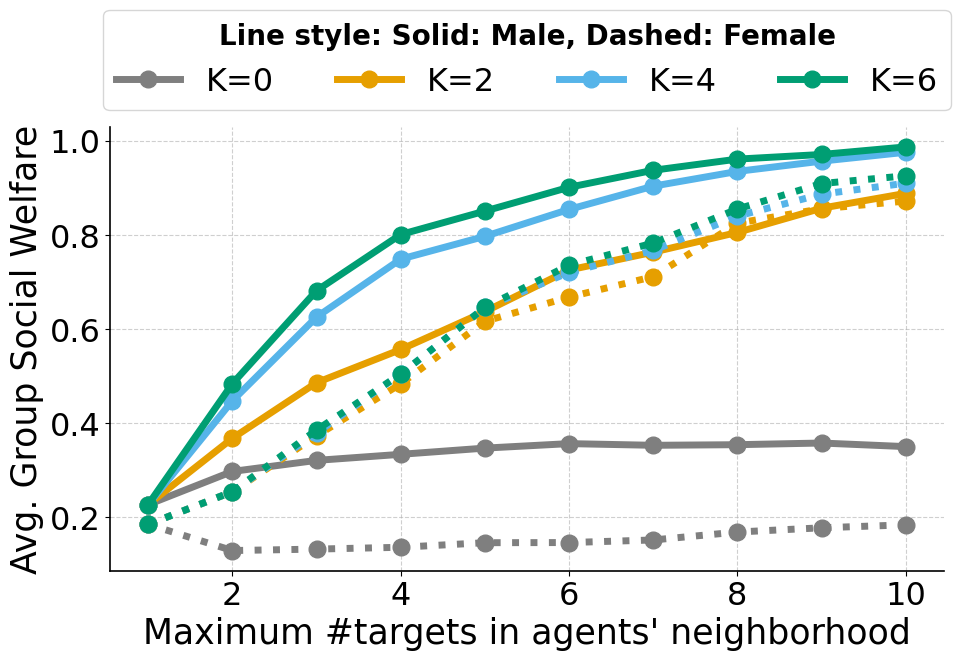

In [21]:
scripts.analytics.plot_fairness(df=resdf["group_results"], 
                                  g1val="g1F(Sg)", 
                                  g0val="g0F(Sg)", 
                                  save_as="./fairness/figures/plot_"+name+"_undivided_budget_knn.pdf",
                                  thresh=False)


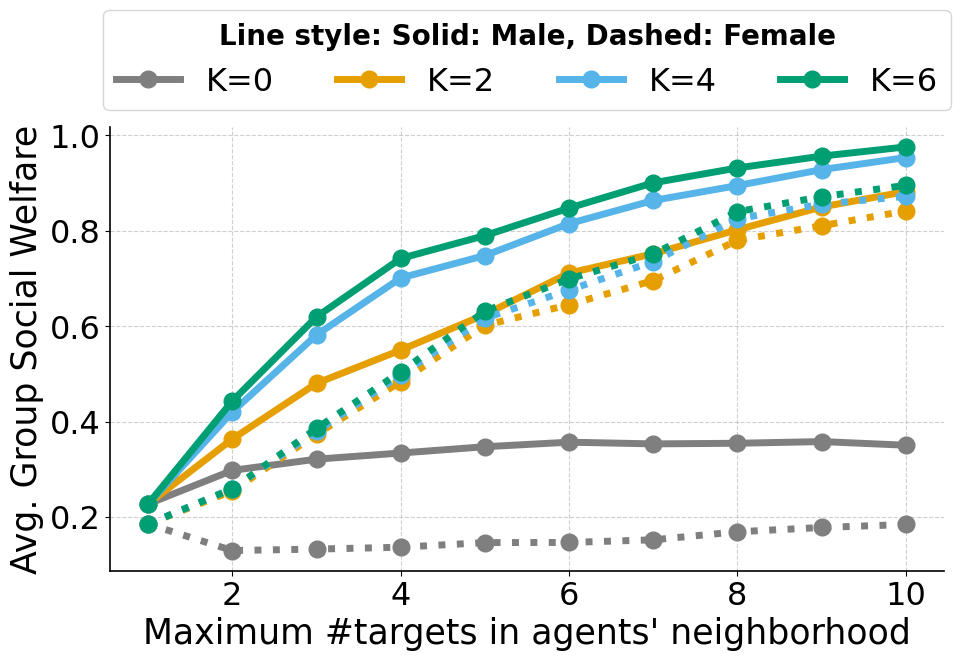

In [22]:
scripts.analytics.plot_fairness(df=resdf["group_results"], 
                                    g1val="g1-F(Sg)", 
                                    g0val="g0-F(Sg)", 
                                    save_as="./fairness/figures/plot_"+name+"_divided_budget_knn.pdf",
                                    thresh=False)

## Thresholding

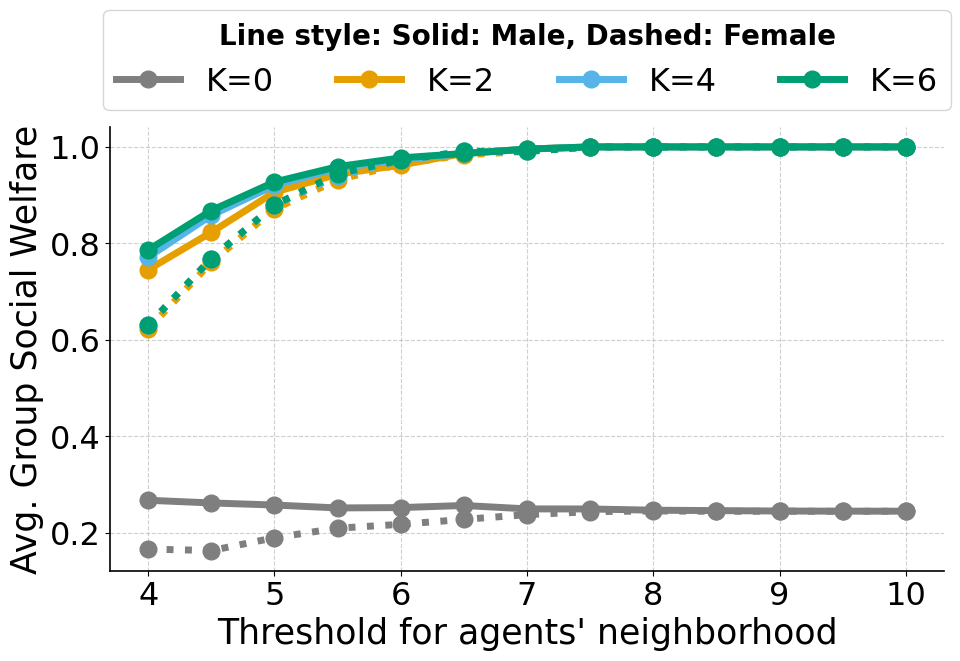

In [23]:
scripts.analytics.plot_fairness(df=resdfx["group_results"], 
                                  g1val="g1F(Sg)", 
                                  g0val="g0F(Sg)", 
                                  save_as="./fairness/figures/plot_"+name+"_undivided_budget_thresh.pdf",
                                  thresh=True)

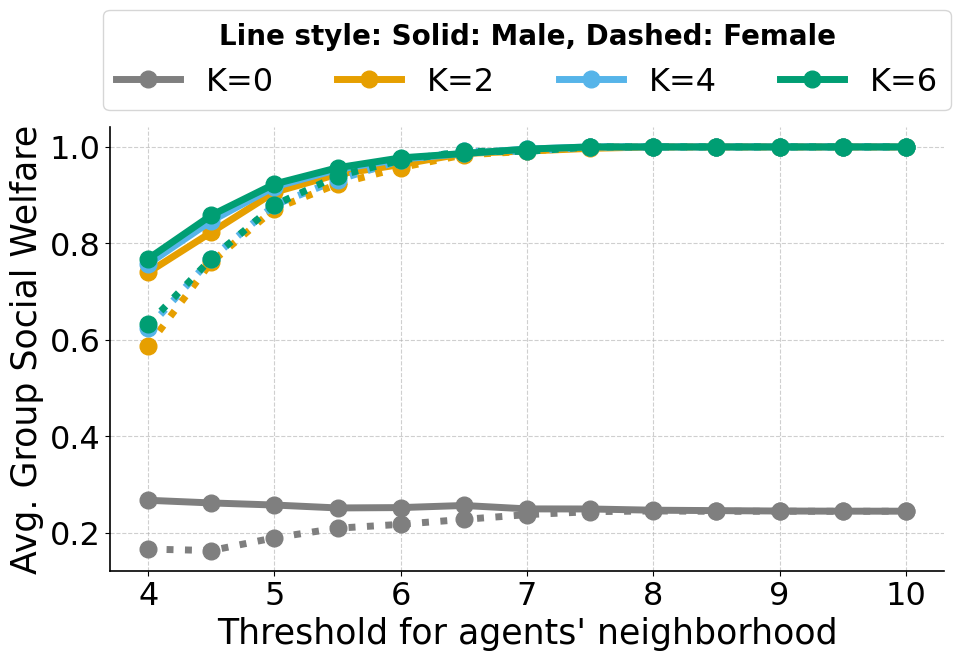

In [24]:
scripts.analytics.plot_fairness(df=resdfx["group_results"], 
                                  g1val="g1-F(Sg)", 
                                  g0val="g0-F(Sg)", 
                                  save_as="./fairness/figures/plot_"+name+"_divided_budget_thresh.pdf",
                                  thresh=True)